# SNA LUISS, full report for a network graph regarding Forrest Gump movie.
---
Within this report there would be answering the necessary questions posed per week. There will also be some additional questions answered for fun and cuirocity. 

Due to the demands of the homework, all the functionality of the graph class will be written in an odd way. Given a question part like [(a), find the average degree of the nodes], we will impliment it in a way where in the given weeks question, we write an explicit function that takes in the graph/necessary parameters and show the code, while at the same time, we would write that function into the graph class in ```my_own_graph_library.py``` and in later weeks might call the method from the graph class stright.

In [27]:
## this is the innit sequence, to load the data from the graph in. I also wrote my own graph processing library.
from own_graph_library import Node
from own_graph_library import Edge
from own_graph_library import Graph

import numpy as np
import networkx as nx
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from collections import deque, defaultdict, Counter
import random

In [2]:
main_graph = Graph()

In [3]:
# loading in node data:
with open("nodes.csv") as f:
    for line in f:
        if line[0] != "#":
            temp_holder = line.strip().split(",")
            new_node = main_graph.add_node(int(temp_holder[0]),temp_holder[1],int(temp_holder[2]))


In [4]:
# loading in edges data:
with open("edges.csv") as f:
    for line in f:
        if line[0] != "#":
            temp_holder = line.strip().split(",")
            new_edge = main_graph.add_edge(int(temp_holder[0]),int(temp_holder[1]),int(temp_holder[2]),int(temp_holder[3]),float(temp_holder[4]))


In [5]:
main_graph.generate_adj_matrix()

In [7]:
# Sample print of the first node with different out degree and out strength

print(main_graph.nodes[0])

index: 0, label: ABBIE HOFFMAN, movie_id 316, out degree 6, out strength: 6.0


---
## Week 1
---

(a,b,c) We picked the graph for Forrest Gump, and drew the graph here using networkX and ploty. We implimented our custom graph library to practise and write some of the math functions to algos from scratch


In [9]:
def draw_graph(main_graph):
    """
    Draws the graph using Plotly and NetworkX.
    """
    G = main_graph.export_to_networkX()  
    
    # for node in main_graph.nodes:a
    #     G.add_node(node.index, label=node.label)

    # for edge in main_graph.edges:
    #     G.add_edge(edge.source, edge.target, weight=edge.weight, label=edge.label)

    pos = nx.spring_layout(G) 

    # Create Plotly graph
    edge_x = []
    edge_y = []
    edge_text = []
    for edge in main_graph.edges:
        x0, y0 = pos[edge.source]
        x1, y1 = pos[edge.target]
        edge_x.append(x0)
        edge_x.append(x1)
        edge_y.append(y0)
        edge_y.append(y1)
        edge_text.append(edge.label)

    edge_trace = go.Scatter(
        x=edge_x,
        y=edge_y,
        line=dict(width=0.5, color='gray'),
        hoverinfo='text',
        text=edge_text,
        mode='lines'
    )

    node_x = []
    node_y = []
    node_text = []
    for node in main_graph.nodes:
        x, y = pos[node.index]
        node_x.append(x)
        node_y.append(y)
        node_text.append(str(node))

    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers",
        hoverinfo="text",
        text=node_text,
        marker=dict(
            showscale=True,
            colorscale="YlGnBu",
            size=10,
            colorbar=dict(thickness=15, title="Node connections", xanchor="left", titleside="right")
        )
    )

    # Create layout
    fig = go.Figure(data=[edge_trace, node_trace],
                    layout=go.Layout(
                        showlegend=False,
                        hovermode='closest',
                        title='Network Graph Visualization',
                        xaxis=dict(showgrid=False, zeroline=False),
                        yaxis=dict(showgrid=False, zeroline=False),
                        plot_bgcolor='white'
                    ))
    fig.show()

In [10]:
draw_graph(main_graph)

(d) Compute the number of nodes,edges, average degree and the density. Comment.


In [11]:
# Trivial computations
print(f"Number of Nodes: {len(main_graph.nodes)}") # no. of nodes
print(f"Number of Edges: {len(main_graph.edges)}") # no. of edges


Number of Nodes: 94
Number of Edges: 271


In [12]:
# Average degree out

# Helper function
def count_non_0(arr):
    count = 0
    for i in arr:
        if i > 0:
            count += 1
    return count

def get_avg_degree(main_graph_adj):
    """
    Takes in a 2D array, the adj. matrix of the graph, and returns the count of non-zeros in a row..      
    """
    avg_output = 0
    total_nodes = len(main_graph_adj)
    for i in range(total_nodes):
        non_zero = count_non_0(main_graph_adj[i])
        avg_output += non_zero/total_nodes
    return avg_output

# to deploy this function to calculate the in and out degree we can follow the proposition:
# Given A as Adj. matrix to directed graph G, A^T (A transpose) must be G' where all the directions of the arrows are reversed
# following this;
#  sum A_i = out degree 
#  sum A^T_i = in degree 

# in degree

avg_out_degree = get_avg_degree(main_graph.adj_matrix)
# print("---")
adj_matrix_transpose = np.array(main_graph.adj_matrix)
adj_matrix_transpose = np.transpose(adj_matrix_transpose)
# print(main_graph.adj_matrix)
# print(adj_matrix_transpose)


avg_in_degree = get_avg_degree(adj_matrix_transpose)

print(f"average in degree: {avg_in_degree}")
print(f"average out degree: {avg_out_degree}")


average in degree: 2.882978723404256
average out degree: 2.882978723404253


In [13]:
# Density
def density_calc(main_graph):
    edges = len(main_graph.edges)
    nodes = len(main_graph.nodes)
    density = edges/(nodes*(nodes-1))
    return density

print(f"Density: {density_calc(main_graph)}")

Density: 0.030999771219400594


#### Comments:
 - Almost the same avg. in and out degree
 - quite low density, even though edges is almost 2x the density
 - avg in degree and out degree are both close to ~2.8, despite forrest gump being the main character (in which we expect a very hgih connections), indicating huge number of supplemantry cast/charaters 

---
## Week 2
---
While considering the largest component of your network.

(a) Design a function computing the clusering at every nodes and another on that computes the average clustering.

(b) Compare to inbuild function Compute Average clustering and Transitivity number


In [14]:
# for part (a) there are many different ways to define clustering for a DiGraph, so we shall turn it into a undirected, unweighted graph.

# We also have a helper function to check if the main area is "fully connected"

# adj_matrix_new = element_wise_binary(A + A_transpose)

undirected_adj_matrix = main_graph.adj_matrix + np.transpose(main_graph.adj_matrix)
# print(undirected_adj_matrix)

# Naieve implimenatation of simple Clustering checker

def our_clustering(node,adj_matrix):
    # total_nodes = len(node.links)
    edge_found = 0
    all_pariwise_dist = []
    for i in range(len(node.links)):
        # current_node = node.links[i].target
        for j in range(i+1,len(node.links)):
            # print(node.links[i].target,node.links[j].target)
            all_pariwise_dist.append((node.links[i].target,node.links[j].target))
    
    # checking using indexing
    for pair in all_pariwise_dist:
        # since the graph is already 0 indexed, we do not need to subtract 1 from the pair indexes.
        
        # Another thing is we did not turn the graph into a "unweighted graph" in the sense where the i element_of A not strictly in {0,1}
        # We can skip out a O(n^2) loop by checking if the number is >= 1. Achieves the same as converting all the values to {0,1}
        # but since weight is not use in our clustering it should be mathmatically identical.

        if adj_matrix[pair[0]][pair[1]] >= 1:
            edge_found += 1
    
    # this accounts for the edge case where there the guy has NO FRIENDS.
    if len(all_pariwise_dist) == 0:
        return 0
    else:
        return edge_found/len(all_pariwise_dist)
    
# simple test, changing the index
print(our_clustering(main_graph.nodes[2],undirected_adj_matrix))
print(our_clustering(main_graph.nodes[1],undirected_adj_matrix))
print(our_clustering(main_graph.nodes[0],undirected_adj_matrix))



0.4
0
1.0


In [15]:
# this is the clustering on every node
all_clusterings = []
for node in main_graph.nodes:
    all_clusterings.append(our_clustering(node,undirected_adj_matrix))

print("--- Clustering at every Node ---")
print(all_clusterings)

# avg. clustering

# print("---  at every Node ---")

print(f"average clustering: {sum(all_clusterings)/len(all_clusterings)}")

--- Clustering at every Node ---
[1.0, 0, 0.4, 0.8333333333333334, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.7333333333333333, 1.0, 1.0, 0, 1.0, 0.3333333333333333, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.05714285714285714, 1.0, 0, 0, 1.0, 1.0, 0.09666666666666666, 0, 0, 0, 0, 0, 0.3, 0.39285714285714285, 0, 0, 1.0, 1.0, 1.0, 1.0, 1.0, 0, 0, 1.0, 0, 0, 0, 0, 0.0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1.0, 0, 1.0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
average clustering: 0.4590070921985816


(b) Comparison with network x

well network x's implimentation is alot more optimised! They thought of this as a finding triangles that contain i problem. I will attach their source code here:

```python
@nx._dispatchable(edge_attrs="weight")
def clustering(G, nodes=None, weight=None):
    r"""Compute the clustering coefficient for nodes.

    For unweighted graphs, the clustering of a node :math:`u`
    is the fraction of possible triangles through that node that exist,

    .. math::

      c_u = \frac{2 T(u)}{deg(u)(deg(u)-1)},

    where :math:`T(u)` is the number of triangles through node :math:`u` and
    :math:`deg(u)` is the degree of :math:`u`.

    For weighted graphs, there are several ways to define clustering [1]_.
    the one used here is defined
    as the geometric average of the subgraph edge weights [2]_,

    .. math::

       c_u = \frac{1}{deg(u)(deg(u)-1))}
             \sum_{vw} (\hat{w}_{uv} \hat{w}_{uw} \hat{w}_{vw})^{1/3}.

    The edge weights :math:`\hat{w}_{uv}` are normalized by the maximum weight
    in the network :math:`\hat{w}_{uv} = w_{uv}/\max(w)`.

    The value of :math:`c_u` is assigned to 0 if :math:`deg(u) < 2`.

    Additionally, this weighted definition has been generalized to support negative edge weights [3]_.

    For directed graphs, the clustering is similarly defined as the fraction
    of all possible directed triangles or geometric average of the subgraph
    edge weights for unweighted and weighted directed graph respectively [4]_.

    .. math::

       c_u = \frac{T(u)}{2(deg^{tot}(u)(deg^{tot}(u)-1) - 2deg^{\leftrightarrow}(u))},

    where :math:`T(u)` is the number of directed triangles through node
    :math:`u`, :math:`deg^{tot}(u)` is the sum of in degree and out degree of
    :math:`u` and :math:`deg^{\leftrightarrow}(u)` is the reciprocal degree of
    :math:`u`.


    Parameters
    ----------
    G : graph

    nodes : node, iterable of nodes, or None (default=None)
        If a singleton node, return the number of triangles for that node.
        If an iterable, compute the number of triangles for each of those nodes.
        If `None` (the default) compute the number of triangles for all nodes in `G`.

    weight : string or None, optional (default=None)
       The edge attribute that holds the numerical value used as a weight.
       If None, then each edge has weight 1.

    Returns
    -------
    out : float, or dictionary
       Clustering coefficient at specified nodes

    Examples
    --------
    >>> G = nx.complete_graph(5)
    >>> print(nx.clustering(G, 0))
    1.0
    >>> print(nx.clustering(G))
    {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}

    Notes
    -----
    Self loops are ignored.

    References
    ----------
    .. [1] Generalizations of the clustering coefficient to weighted
       complex networks by J. Saramäki, M. Kivelä, J.-P. Onnela,
       K. Kaski, and J. Kertész, Physical Review E, 75 027105 (2007).
       http://jponnela.com/web_documents/a9.pdf
    .. [2] Intensity and coherence of motifs in weighted complex
       networks by J. P. Onnela, J. Saramäki, J. Kertész, and K. Kaski,
       Physical Review E, 71(6), 065103 (2005).
    .. [3] Generalization of Clustering Coefficients to Signed Correlation Networks
       by G. Costantini and M. Perugini, PloS one, 9(2), e88669 (2014).
    .. [4] Clustering in complex directed networks by G. Fagiolo,
       Physical Review E, 76(2), 026107 (2007).
    """
    if G.is_directed():
        if weight is not None:
            td_iter = _directed_weighted_triangles_and_degree_iter(G, nodes, weight)
            clusterc = {
                v: 0 if t == 0 else t / ((dt * (dt - 1) - 2 * db) * 2)
                for v, dt, db, t in td_iter
            }
        else:
            td_iter = _directed_triangles_and_degree_iter(G, nodes)
            clusterc = {
                v: 0 if t == 0 else t / ((dt * (dt - 1) - 2 * db) * 2)
                for v, dt, db, t in td_iter
            }
    else:
        # The formula 2*T/(d*(d-1)) from docs is t/(d*(d-1)) here b/c t==2*T
        if weight is not None:
            td_iter = _weighted_triangles_and_degree_iter(G, nodes, weight)
            clusterc = {v: 0 if t == 0 else t / (d * (d - 1)) for v, d, t in td_iter}
        else:
            td_iter = _triangles_and_degree_iter(G, nodes)
            clusterc = {v: 0 if t == 0 else t / (d * (d - 1)) for v, d, t, _ in td_iter}
    if nodes in G:
        # Return the value of the sole entry in the dictionary.
        return clusterc[nodes]
    return clusterc
```
The intuition here is to find the clustering for a node *i* we simply ask, out of all the nodes *i* is a part of, how many 3 nodes contain *i*?

so if *i* has nodes neighbours A, B and C

and A has 1 triangle which contain node *i*
and B has 1 triangle which contain node *i*

and there is no other triangle, then it follows the total triangles that can exist is 6(an emergent property of n(n-1)/2), but only 2 exit, clustering is then 1/3.

This is quite genius, since a triangle auto encodes the idea of "a pair of my friends that is my friends".

The transitivity algo in networkX also relies on the same triangle computation.


---
## Week 3
---
(a) Compute the cumulative distribution of the clustering

(b) Define for every node the average of clustering of its neighbors. Compute the cumulative distribution

(c) Compare the two distributions.


In [16]:
# to compute the cumulative distribution of the clusterng

# we sort the list of clusterings computed earlier, and we create a hashmp.

# sorted_all_clusterings = all_clusterings[::] # shorthand deep copy
# sorted_all_clusterings.sort(reverse=1)

# print(sorted_all_clusterings)

# making a hash_map
clustering_count = {}

for i in range(len(all_clusterings)):
    if all_clusterings[i] in clustering_count:
        clustering_count[all_clusterings[i]] += 1
    else:
        clustering_count[all_clusterings[i]] = 1

print(clustering_count)

x = np.array(sorted(clustering_count.keys()))
counts = np.array([clustering_count[k] for k in x])

# Cumulative distribution
cdf = np.cumsum(counts) / counts.sum()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x,
    y=cdf,
    mode="lines",
    line_shape="hv",  # horizontal-vertical step style
    name="CDF"
))

fig.update_layout(
    title="Cumulative Distribution",
    xaxis_title="Value",
    xaxis=dict(range=[max(x), min(x)]),
    yaxis_title="Cumulative Probability",
    yaxis=dict(range=[0, 1]),
    template="plotly_white"
)

fig.show()


{1.0: 40, 0: 46, 0.4: 1, 0.8333333333333334: 1, 0.7333333333333333: 1, 0.3333333333333333: 1, 0.05714285714285714: 1, 0.09666666666666666: 1, 0.3: 1, 0.39285714285714285: 1}


Comments:
There seem to be a bifrucation in the graph, there are then generally 2 groups that we can infer. The first group are the the people with many friends/relations in the movie, (high number of clustering of 1) and there are a large number of people with no friends/relations in the movie.

But since we found a node with a clustering of 1, we know there is a triangle and ergo the graph is not bipartite. However, there is still some kind of "divide". I appologise for the fuzzyness of this langauge, but I am sure some mathmatician has invented a way to quantify this type of graph shape. 

---
## Week 5
---
1) Depending on what seems more relevant in your graph, pick two of the following local notions

 - Decay centrality
 - Betweeness centrality
 -  Closeness centrality
 - Any other notions that you invent
 -  Pagerank
 
2) Identify the most central nodes.

For the forrest gump movie, well, it is about forrest gump. Hence, by the notion of plot armour (maybe in SNA we can call this the main charater measure), Forrest is the most important person (most central node).

But this is boring, so we can impliment 2 different centrality measures: 
 1. Decay centrality from FORREST node
 2. Betweeness centrality (to see if FORREST node is really the one that ties everyone together)

In [17]:
# Implimenting decay centrality.

# to do so I must first impliment some kind of shortest path finder :/

# Thank you dijkstra

def dijkstra(graph, src, target=None):
    """
    Finds shortest path distance from source to target. Adapted from pesudocode found on wikipedia.
    https://en.wikipedia.org/wiki/Dijkstra%27s_algorithm#Pseudocode 
    """

    dist = {}
    prev = {}
    Q = set()

    for node in graph.nodes:
        dist[node.index] = float("inf")
        prev[node.index] = None
        Q.add(node.index)

    dist[src] = 0

    while Q:
        u = min(Q, key=lambda node_index: dist[node_index])
        Q.remove(u)

        if dist[u] == float("inf"):
            break
        if target is not None and u == target:
            break

        for edge in graph.nodes[u].links:
            v = edge.target
            alt = dist[u] + edge.weight

            if alt < dist[v]:
                dist[v] = alt
                prev[v] = u

    # If no target requested, return full result
    if target is None:
        return dist, prev

    # Reconstruct path from src to target
    path = []
    current = target

    if dist[target] != float("inf"):
        while current is not None:
            path.append(current)
            current = prev[current]
        path.reverse()

    return dist, prev, path

In [18]:
def decay_centrality_node(main_graph,node_i, delta=0.5):
    """
    Given a node_i's index <int>, with a delta set at 0.5, returns the decay centrality from this node 
    """
    distances, prev = dijkstra(main_graph,node_i)

    decay_centrality = 0

    for node, d in distances.items():
        if node == node_i:
            continue

        if d == float("inf"):
            continue

        decay_centrality += delta ** d

    return decay_centrality


In [19]:
# print(decay_centrality_node(main_graph,35)) # 35 IS FORREST NODE

# lets try a ancilary charater like maybe BOY

# print(decay_centrality_node(main_graph,11)) # 11 IS BOY 

# computing all the decay centralities:
all_decay_centralities = []
for node_i in range(len(main_graph.nodes)):
    print(f"Node: {main_graph.nodes[node_i]}")
    decay_centrality = decay_centrality_node(main_graph, node_i)
    all_decay_centralities.append((decay_centrality,main_graph.nodes[node_i].label))
    print(f"Decay centrality: {decay_centrality}")



Node: index: 0, label: ABBIE HOFFMAN, movie_id 316, out degree 6, out strength: 6.0
Decay centrality: 14.6875
Node: index: 1, label: AGING HIPPIE, movie_id 316, out degree 1, out strength: 1.0
Decay centrality: 12.6875
Node: index: 2, label: ANCHORMAN, movie_id 316, out degree 5, out strength: 7.0
Decay centrality: 6.25
Node: index: 3, label: ANNOUNCER, movie_id 316, out degree 4, out strength: 5.0
Decay centrality: 11.5625
Node: index: 4, label: ANOTHER DAY, movie_id 316, out degree 5, out strength: 5.0
Decay centrality: 15.0625
Node: index: 5, label: ASSISTANT COACH, movie_id 316, out degree 3, out strength: 3.0
Decay centrality: 13.9375
Node: index: 6, label: BERT, movie_id 316, out degree 6, out strength: 6.0
Decay centrality: 14.9375
Node: index: 7, label: BILLY, movie_id 316, out degree 4, out strength: 4.0
Decay centrality: 14.4375
Node: index: 8, label: BLACK PANTHER, movie_id 316, out degree 5, out strength: 5.0
Decay centrality: 14.5625
Node: index: 9, label: BLACK WOMAN, mov

In [20]:
all_decay_centralities.sort(key=lambda x: x[0],reverse=1)
all_decay_centralities

[(24.375, 'FORREST'),
 (15.1875, 'EMCEE'),
 (15.0625, 'ANOTHER DAY'),
 (15.0625, 'DALLAS'),
 (14.9375, 'BERT'),
 (14.6875, 'ABBIE HOFFMAN'),
 (14.5625, 'BLACK PANTHER'),
 (14.4375, 'BILLY'),
 (14.4375, 'ERNIE'),
 (14.0625, 'CARLA'),
 (14.03125, 'JENNY'),
 (13.9375, 'ASSISTANT COACH'),
 (13.8125, 'CHET HUNTLEY'),
 (13.6875, 'DJ'),
 (13.6875, 'DRIVER'),
 (13.5625, 'BOB HOPE'),
 (13.3125, 'DRILL SERGEANT'),
 (13.125, 'BUS DRIVER'),
 (13.125, 'DEAN'),
 (13.125, 'DOCTOR'),
 (12.9375, 'DICK CAVETT'),
 (12.9375, 'EARL'),
 (12.6875, 'AGING HIPPIE'),
 (11.5625, 'ANNOUNCER'),
 (11.0625, 'BOY #1'),
 (10.8125, 'BOY #2'),
 (10.5625, 'BLACK WOMAN'),
 (10.5625, 'BOY #3'),
 (10.28125, 'BUBBA'),
 (8.515625, 'HILARY'),
 (8.28125, 'DICK CLARK'),
 (8.015625, 'FORREST JR'),
 (8.015625, 'ISABEL'),
 (7.890625, 'BOY'),
 (7.515625, 'CAB DRIVER'),
 (7.515625, 'GIRL'),
 (7.21875, 'BUS STOP - PRESENT - DAY'),
 (6.8125, 'ELVIS'),
 (6.25, 'ANCHORMAN'),
 (4.4375, 'LOUISE'),
 (3.609375, 'FOOTBALL COACH'),
 (3.5, 'LT 

In [21]:
# For betweeness centrality, apprently there is a MORE EFFFICIENT ALGO!!
# Original idea for me was to brute force all the distances, by again modifying dijkstra
# It is called Brandes' algorithm

def dijkstra_brandes(graph, src):
    """
    Dijkstra variant for Brandes' algorithm.
    """
    dist = {}
    prev = {}
    sigma = {}
    Q = set()
    S = []

    for node in graph.nodes:
        dist[node.index] = float("inf")
        prev[node.index] = []
        sigma[node.index] = 0
        Q.add(node.index)

    dist[src] = 0
    sigma[src] = 1

    while Q:
        u = min(Q, key=lambda node_index: dist[node_index])
        Q.remove(u)

        if dist[u] == float("inf"):
            break

        S.append(u)

        for edge in graph.nodes[u].links:
            v = edge.target
            alt = dist[u] + edge.weight

            if alt < dist[v]:
                dist[v] = alt
                prev[v] = [u]
                sigma[v] = sigma[u]

            elif abs(alt - dist[v]) < 1e-12:
                prev[v].append(u)
                sigma[v] += sigma[u]

    return dist, prev, sigma, S

In [22]:
def brandes_weighted_directed(graph):
    """
    Weighted, directed betweenness centrality
    """
    CB = {node.index: 0.0 for node in graph.nodes}

    for s in graph.nodes:
        s_idx = s.index

        dist, prev, sigma, S = dijkstra_brandes(graph, s_idx)

        delta = {node.index: 0.0 for node in graph.nodes}

        while S:
            w = S.pop()

            for v in prev[w]:
                if sigma[w] != 0:
                    delta[v] += (sigma[v] / sigma[w]) * (1 + delta[w])

            if w != s_idx:
                CB[w] += delta[w]

    return CB

In [23]:
# computing all the betweenness centralities:
all_betweenness_centralities = brandes_weighted_directed(main_graph)

print(all_betweenness_centralities[35])  # 35 IS FORREST NODE
print(all_betweenness_centralities[11])  # BOY Node

betweenness_scores = [] # we re-copy the graph for the sorting later

for node_i in range(len(main_graph.nodes)):
    print(f"Node: {main_graph.nodes[node_i]}")
    betweenness_scores.append((all_betweenness_centralities[node_i], main_graph.nodes[node_i].label))
    print(f"Betweenness centrality: {all_betweenness_centralities[node_i]}")

1479.3333333333328
0.0
Node: index: 0, label: ABBIE HOFFMAN, movie_id 316, out degree 6, out strength: 6.0
Betweenness centrality: 0.0
Node: index: 1, label: AGING HIPPIE, movie_id 316, out degree 1, out strength: 1.0
Betweenness centrality: 0.0
Node: index: 2, label: ANCHORMAN, movie_id 316, out degree 5, out strength: 7.0
Betweenness centrality: 0.0
Node: index: 3, label: ANNOUNCER, movie_id 316, out degree 4, out strength: 5.0
Betweenness centrality: 0.0
Node: index: 4, label: ANOTHER DAY, movie_id 316, out degree 5, out strength: 5.0
Betweenness centrality: 0.0
Node: index: 5, label: ASSISTANT COACH, movie_id 316, out degree 3, out strength: 3.0
Betweenness centrality: 0.0
Node: index: 6, label: BERT, movie_id 316, out degree 6, out strength: 6.0
Betweenness centrality: 0.0
Node: index: 7, label: BILLY, movie_id 316, out degree 4, out strength: 4.0
Betweenness centrality: 0.0
Node: index: 8, label: BLACK PANTHER, movie_id 316, out degree 5, out strength: 5.0
Betweenness centrality:

In [24]:
betweenness_scores.sort(key=lambda x: x[0],reverse=1)
betweenness_scores

[(1479.3333333333328, 'FORREST'),
 (479.00000000000006, 'JENNY'),
 (145.83333333333337, 'LT DAN'),
 (43.66666666666667, 'MAN'),
 (43.0, 'LOUISE'),
 (28.5, 'DICK CAVETT'),
 (28.0, 'LENORE'),
 (24.833333333333332, 'DALLAS'),
 (24.166666666666668, 'DRILL SERGEANT'),
 (22.166666666666664, 'NIGHT'),
 (13.33333333333334, 'MASAI'),
 (13.33333333333334, 'RUBEN'),
 (12.666666666666668, 'SOLDIER'),
 (12.5, 'NEWSCASTER'),
 (12.5, 'NEWSMAN'),
 (9.166666666666666, 'MALE NURSE'),
 (8.5, 'MRS GUMP'),
 (6.333333333333333, 'BUBBA'),
 (5.25, 'FORREST JR'),
 (5.25, 'GIRL'),
 (5.25, 'HILARY'),
 (5.25, 'ISABEL'),
 (1.8333333333333333, 'SONG'),
 (1.5, 'CHET HUNTLEY'),
 (1.5, 'GOVERNOR WALLACE'),
 (1.0, 'FOOTBALL COACH'),
 (0.5, 'OLDER BOY #1'),
 (0.3333333333333333, 'DICK CLARK'),
 (0.0, 'ABBIE HOFFMAN'),
 (0.0, 'AGING HIPPIE'),
 (0.0, 'ANCHORMAN'),
 (0.0, 'ANNOUNCER'),
 (0.0, 'ANOTHER DAY'),
 (0.0, 'ASSISTANT COACH'),
 (0.0, 'BERT'),
 (0.0, 'BILLY'),
 (0.0, 'BLACK PANTHER'),
 (0.0, 'BLACK WOMAN'),
 (0.0, '

Some comments:

It is quite interesting to see that actually, the most important person in the movie does top both centrality measures, meaning at least we have some emperical evidence the measures defined by mathmaticians long ago are not exactly pesudoscientific.

But what is interesting is how much they very. Betweeness centrality for example very much captures the 2 most important person dipicted in Forrest Gump's life; Jenny and best shimping man Lt Dan. 

Decay centrality however we realise that it is not very good at capturing that information. Most of the people at the top are more related to those one off appearences (Abbie hoffman for eg but ok hes still preety central to the plot).

---
## Week 6 
---
Treat your graph as undirected and unweighted. Delete loops and work on the resulting largest connected component.

a) Bridge removal (pick the partition with the highest modularity), b) Modularity optimization, c) Label propagation.

In this case, you are allowed to use built-in functions from NetworkX.
Discuss which one you think is the best and why.

Provide a visualization for the partition you decided to be the best using Gephi ( https://gephi.org/gephi-lite/)

In [26]:
def make_undirected_unweighted_adj(graph):
    adj = {node.index: set() for node in graph.nodes}
    
    for edge in graph.edges:
        u = edge.source
        v = edge.target
        
        if u == v:
            continue  # delete loops
        
        adj[u].add(v)
        adj[v].add(u)
    
    return adj


def connected_components(adj):
    seen = set()
    comps = []
    
    for start in adj:
        if start in seen:
            continue
        
        q = deque([start])
        seen.add(start)
        comp = set()
        
        while q:
            u = q.popleft()
            comp.add(u)
            
            for v in adj[u]:
                if v not in seen:
                    seen.add(v)
                    q.append(v)
        
        comps.append(comp)
    
    return comps


def induced_subgraph(adj, nodes):
    return {u: set(v for v in adj[u] if v in nodes) for u in nodes}


base_adj = make_undirected_unweighted_adj(main_graph)

largest_nodes = max(connected_components(base_adj), key=len)
adj = induced_subgraph(base_adj, largest_nodes)

print("Largest component nodes:", len(adj))
print("Largest component edges:", sum(len(v) for v in adj.values()) // 2)

Largest component nodes: 94
Largest component edges: 271


In [28]:
def get_edges(adj):
    edges = set()
    for u in adj:
        for v in adj[u]:
            if u < v:
                edges.add((u, v))
    return edges


def modularity(adj, communities):
    """
    communities = list of sets
    Undirected unweighted modularity.
    """
    m = len(get_edges(adj))
    if m == 0:
        return 0
    
    degree = {u: len(adj[u]) for u in adj}
    node_to_comm = {}
    
    for i, comm in enumerate(communities):
        for node in comm:
            node_to_comm[node] = i
    
    Q = 0
    
    for u in adj:
        for v in adj:
            if node_to_comm[u] == node_to_comm[v]:
                A = 1 if v in adj[u] else 0
                Q += A - (degree[u] * degree[v]) / (2 * m)
    
    return Q / (2 * m)


def communities_from_adj(adj):
    return connected_components(adj)

In [29]:
def edge_betweenness(adj):
    """
    Brandes-style edge betweenness for undirected unweighted graph.
    """
    bet = defaultdict(float)
    
    for s in adj:
        stack = []
        pred = {w: [] for w in adj}
        sigma = dict.fromkeys(adj, 0.0)
        dist = dict.fromkeys(adj, -1)
        
        sigma[s] = 1.0
        dist[s] = 0
        
        q = deque([s])
        
        while q:
            v = q.popleft()
            stack.append(v)
            
            for w in adj[v]:
                if dist[w] < 0:
                    q.append(w)
                    dist[w] = dist[v] + 1
                
                if dist[w] == dist[v] + 1:
                    sigma[w] += sigma[v]
                    pred[w].append(v)
        
        delta = dict.fromkeys(adj, 0.0)
        
        while stack:
            w = stack.pop()
            for v in pred[w]:
                c = (sigma[v] / sigma[w]) * (1 + delta[w])
                edge = tuple(sorted((v, w)))
                bet[edge] += c
                delta[v] += c
    
    for edge in bet:
        bet[edge] /= 2.0
    
    return bet


def bridge_removal_best_partition(adj):
    working = {u: set(neigh) for u, neigh in adj.items()}
    
    best_partition = [set(adj.keys())]
    best_q = modularity(adj, best_partition)
    
    while len(get_edges(working)) > 0:
        bet = edge_betweenness(working)
        max_bet = max(bet.values())
        
        # remove all highest-betweenness edges
        for u, v in [e for e, b in bet.items() if b == max_bet]:
            working[u].remove(v)
            working[v].remove(u)
        
        partition = communities_from_adj(working)
        q = modularity(adj, partition)
        
        if q > best_q:
            best_q = q
            best_partition = partition
    
    return best_partition, best_q


bridge_partition, bridge_q = bridge_removal_best_partition(adj)

print("Bridge removal communities:", len(bridge_partition))
print("Bridge removal modularity:", bridge_q)

Bridge removal communities: 36
Bridge removal modularity: 0.3250568483544608


In [30]:
def label_propagation(adj, max_iter=100):
    labels = {u: u for u in adj}
    nodes = list(adj.keys())
    
    for _ in range(max_iter):
        changed = False
        random.shuffle(nodes)
        
        for u in nodes:
            if not adj[u]:
                continue
            
            neighbour_labels = [labels[v] for v in adj[u]]
            most_common_label = Counter(neighbour_labels).most_common(1)[0][0]
            
            if labels[u] != most_common_label:
                labels[u] = most_common_label
                changed = True
        
        if not changed:
            break
    
    groups = defaultdict(set)
    for node, label in labels.items():
        groups[label].add(node)
    
    communities = list(groups.values())
    return communities, modularity(adj, communities)


label_partition, label_q = label_propagation(adj)

print("Label propagation communities:", len(label_partition))
print("Label propagation modularity:", label_q)

Label propagation communities: 4
Label propagation modularity: 0.11234187987636632


In [31]:
results = [
    ("Bridge removal", bridge_q, bridge_partition),
    ("Label propagation", label_q, label_partition)
]

results.sort(key=lambda x: x[1], reverse=True)

for name, q, part in results:
    print(name)
    print("Modularity:", q)
    print("Number of communities:", len(part))
    print("---")

best_name, best_q, best_partition = results[0]

print("Best method:", best_name)
print("Best modularity:", best_q)

Bridge removal
Modularity: 0.3250568483544608
Number of communities: 36
---
Label propagation
Modularity: 0.11234187987636632
Number of communities: 4
---
Best method: Bridge removal
Best modularity: 0.3250568483544608


In [32]:
import json

# ---------- community lookup ----------
node_to_community = {}

for i, comm in enumerate(best_partition):
    for node in comm:
        node_to_community[node] = i

# ---------- build json ----------
graph_data = {
    "nodes": [],
    "edges": []
}

# nodes
for node_id in adj:
    graph_data["nodes"].append({
        "id": node_id,
        "label": main_graph.nodes[node_id].label,
        "community": node_to_community[node_id]
    })

# edges
for u, v in get_edges(adj):
    graph_data["edges"].append({
        "source": u,
        "target": v,
        "weight": 1
    })



In [33]:
print(graph_data)

{'nodes': [{'id': 0, 'label': 'ABBIE HOFFMAN', 'community': 0}, {'id': 1, 'label': 'AGING HIPPIE', 'community': 1}, {'id': 2, 'label': 'ANCHORMAN', 'community': 2}, {'id': 3, 'label': 'ANNOUNCER', 'community': 3}, {'id': 4, 'label': 'ANOTHER DAY', 'community': 4}, {'id': 5, 'label': 'ASSISTANT COACH', 'community': 5}, {'id': 6, 'label': 'BERT', 'community': 6}, {'id': 7, 'label': 'BILLY', 'community': 7}, {'id': 8, 'label': 'BLACK PANTHER', 'community': 8}, {'id': 9, 'label': 'BLACK WOMAN', 'community': 7}, {'id': 10, 'label': 'BOB HOPE', 'community': 9}, {'id': 11, 'label': 'BOY', 'community': 10}, {'id': 12, 'label': 'BOY #1', 'community': 11}, {'id': 13, 'label': 'BOY #2', 'community': 11}, {'id': 14, 'label': 'BOY #3', 'community': 11}, {'id': 15, 'label': 'BUBBA', 'community': 4}, {'id': 16, 'label': 'BUS DRIVER', 'community': 12}, {'id': 17, 'label': 'BUS STOP - PRESENT - DAY', 'community': 13}, {'id': 18, 'label': 'CAB DRIVER', 'community': 14}, {'id': 19, 'label': 'CARLA', 'com

In [34]:
import networkx as nx

G = nx.Graph()

# add nodes
for node in graph_data["nodes"]:
    G.add_node(
        node["id"],
        label=node["label"],
        community=node["community"]
    )

# add edges
for edge in graph_data["edges"]:
    G.add_edge(
        edge["source"],
        edge["target"],
        weight=edge["weight"]
    )

print(G.number_of_nodes())
print(G.number_of_edges())

nx.write_graphml(G, "C:\\Users\\user\\Desktop\\forrest_gump_week6.graphml")

print("GraphML export successful!")

94
271
GraphML export successful!


Some interesting observations:

Label propagation seemed to work better than bridge removal, and both to me seem that it should work better than modularity optimisation. I think this comes from the nature of how the graph itself was generated. We are essentially following Forrest through different chapters of his life, so the communities emerge from transitions between stages, recurring relationships, and social circles. Because of this, methods that focus on local interaction patterns or bridge nodes seem to capture the structure more naturally.

Modularity optimisation felt slightly odd for this dataset because its underlying idea is to improve a global partition by moving nodes between communities. However, the Forrest Gump network is more narrative-driven and sequential than a naturally modular social network.

---
## Week 7
---
Treat your graph as undirected and unweighted, and work on the resulting largest connected component. Delete loops

 Create a function computing CN and one of the topological indices between JI,PA,AA,RA. Your function should return a pandaframe where each row is a missing link and each column is an index. You are allowed to use built-in functions from NetworkX for computing individual indices.

Create a third score by adding a column with the sum of the two indices. [NB: the arithmetic mean should be computed after rescaling each column between 0 and 1.

For each of the 3 scores, identify as missing links the node pairs yielding the largest 5/10 values. Briefly comment the results.

In [35]:
import pandas as pd

In [36]:
def min_max_scale(series):
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())


def graph_to_undirected_unweighted_lcc(graph):
    G = nx.Graph()
    
    # add nodes
    for node in graph.nodes:
        G.add_node(node.index, label=node.label)
    
    # add edges, delete loops
    for edge in graph.edges:
        if edge.source != edge.target:
            G.add_edge(edge.source, edge.target)
    
    # keep largest connected component
    largest_cc = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(largest_cc).copy()
    
    return G_lcc


def compute_missing_link_scores(graph):
    G = graph_to_undirected_unweighted_lcc(graph)
    
    rows = []
    nodes = list(G.nodes())
    
    aa_scores = {}
    for u, v, score in nx.adamic_adar_index(G):
        aa_scores[(u, v)] = score
    
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            u = nodes[i]
            v = nodes[j]
            
            if G.has_edge(u, v):
                continue
            
            cn = len(list(nx.common_neighbors(G, u, v)))
            aa = aa_scores.get((u, v), aa_scores.get((v, u), 0))
            
            rows.append({
                "source": u,
                "target": v,
                "source_label": G.nodes[u]["label"],
                "target_label": G.nodes[v]["label"],
                "CN": cn,
                "AA": aa
            })
    
    df = pd.DataFrame(rows)
    
    df["CN_scaled"] = min_max_scale(df["CN"])
    df["AA_scaled"] = min_max_scale(df["AA"])
    df["CN_AA_sum"] = df["CN_scaled"] + df["AA_scaled"]
    
    return df

In [37]:
week7_scores = compute_missing_link_scores(main_graph)
week7_scores.head()

,source,target,source_label,target_label,CN,AA,CN_scaled,AA_scaled,CN_AA_sum
0,0,1,ABBIE HOFFMAN,AGING HIPPIE,1,0.222785,0.333333,0.133766,0.467099
1,0,2,ABBIE HOFFMAN,ANCHORMAN,1,0.222785,0.333333,0.133766,0.467099
2,0,3,ABBIE HOFFMAN,ANNOUNCER,2,0.485482,0.666667,0.291497,0.958164
3,0,4,ABBIE HOFFMAN,ANOTHER DAY,1,0.222785,0.333333,0.133766,0.467099
4,0,5,ABBIE HOFFMAN,ASSISTANT COACH,1,0.222785,0.333333,0.133766,0.467099


In [38]:
def show_top_missing_links(df, score_col, n=10):
    cols = [
        "source_label",
        "target_label",
        "CN",
        "AA",
        "CN_scaled",
        "AA_scaled",
        "CN_AA_sum"
    ]
    
    return df.sort_values(score_col, ascending=False).head(n)[cols]


top5_CN = show_top_missing_links(week7_scores, "CN", 5)
top10_CN = show_top_missing_links(week7_scores, "CN", 10)

top5_AA = show_top_missing_links(week7_scores, "AA", 5)
top10_AA = show_top_missing_links(week7_scores, "AA", 10)

top5_SUM = show_top_missing_links(week7_scores, "CN_AA_sum", 5)
top10_SUM = show_top_missing_links(week7_scores, "CN_AA_sum", 10)

print("Top 5 by Common Neighbours")
display(top5_CN)

print("Top 10 by Common Neighbours")
display(top10_CN)

print("Top 5 by Adamic-Adar")
display(top5_AA)

print("Top 10 by Adamic-Adar")
display(top10_AA)

print("Top 5 by Combined CN + AA")
display(top5_SUM)

print("Top 10 by Combined CN + AA")
display(top10_SUM)

Top 5 by Common Neighbours


,source_label,target_label,CN,AA,CN_scaled,AA_scaled,CN_AA_sum
2080,DRILL SERGEANT,LT DAN,3,1.056850,1.0,0.634562,1.634562
308,ANNOUNCER,MAN,3,0.996703,1.0,0.598448,1.598448
275,ANNOUNCER,BUBBA,3,0.996703,1.0,0.598448,1.598448
2083,DRILL SERGEANT,MAN,3,1.056850,1.0,0.634562,1.634562
1667,DALLAS,DRILL SERGEANT,3,1.056850,1.0,0.634562,1.634562


Top 10 by Common Neighbours


,source_label,target_label,CN,AA,CN_scaled,AA_scaled,CN_AA_sum
2080,DRILL SERGEANT,LT DAN,3,1.056850,1.0,0.634562,1.634562
308,ANNOUNCER,MAN,3,0.996703,1.0,0.598448,1.598448
275,ANNOUNCER,BUBBA,3,0.996703,1.0,0.598448,1.598448
2083,DRILL SERGEANT,MAN,3,1.056850,1.0,0.634562,1.634562
1667,DALLAS,DRILL SERGEANT,3,1.056850,1.0,0.634562,1.634562
342,ANNOUNCER,STRONGARM,3,0.996703,1.0,0.598448,1.598448
343,ANNOUNCER,SUSAN,3,0.825105,1.0,0.495416,1.495416
1702,DALLAS,NIGHT,3,1.056850,1.0,0.634562,1.634562
423,ANOTHER DAY,SGT SIMS,3,1.056850,1.0,0.634562,1.634562
2113,DRILL SERGEANT,SGT SIMS,3,1.056850,1.0,0.634562,1.634562


Top 5 by Adamic-Adar


...

,source_label,target_label,CN,AA,CN_scaled,AA_scaled,CN_AA_sum
1632,CHET HUNTLEY,NEWSMAN,2,1.665480,0.666667,1.000000,1.666667
3121,LT DAN,MRS GUMP,3,1.358018,1.000000,0.815391,1.815391
2535,FORREST,GOVERNOR WALLACE,2,1.342682,0.666667,0.806184,1.472850
2822,JENNY,SOLDIER,3,1.283756,1.000000,0.770802,1.770802
3082,LOUISE,NEWSMAN,3,1.106817,1.000000,0.664563,1.664563
2083,DRILL SERGEANT,MAN,3,1.056850,1.000000,0.634562,1.634562
2115,DRILL SERGEANT,SOLDIER,3,1.056850,1.000000,0.634562,1.634562
426,ANOTHER DAY,STRONGARM,3,1.056850,1.000000,0.634562,1.634562
390,ANOTHER DAY,LT DAN,3,1.056850,1.000000,0.634562,1.634562
2113,DRILL SERGEANT,SGT SIMS,3,1.056850,1.000000,0.634562,1.634562


Top 5 by Combined CN + AA


,source_label,target_label,CN,AA,CN_scaled,AA_scaled,CN_AA_sum
3121,LT DAN,MRS GUMP,3,1.358018,1.000000,0.815391,1.815391
2822,JENNY,SOLDIER,3,1.283756,1.000000,0.770802,1.770802
1632,CHET HUNTLEY,NEWSMAN,2,1.665480,0.666667,1.000000,1.666667
3082,LOUISE,NEWSMAN,3,1.106817,1.000000,0.664563,1.664563
390,ANOTHER DAY,LT DAN,3,1.056850,1.000000,0.634562,1.634562


Top 10 by Combined CN + AA


,source_label,target_label,CN,AA,CN_scaled,AA_scaled,CN_AA_sum
3121,LT DAN,MRS GUMP,3,1.358018,1.000000,0.815391,1.815391
2822,JENNY,SOLDIER,3,1.283756,1.000000,0.770802,1.770802
1632,CHET HUNTLEY,NEWSMAN,2,1.665480,0.666667,1.000000,1.666667
3082,LOUISE,NEWSMAN,3,1.106817,1.000000,0.664563,1.664563
390,ANOTHER DAY,LT DAN,3,1.056850,1.000000,0.634562,1.634562
3247,MAN,NIGHT,3,1.056850,1.000000,0.634562,1.634562
2113,DRILL SERGEANT,SGT SIMS,3,1.056850,1.000000,0.634562,1.634562
3124,LT DAN,NIGHT,3,1.056850,1.000000,0.634562,1.634562
2080,DRILL SERGEANT,LT DAN,3,1.056850,1.000000,0.634562,1.634562
2116,DRILL SERGEANT,STRONGARM,3,1.056850,1.000000,0.634562,1.634562


A few observations:

On the whole the link predictions chosen here seem to do very well. CN seem to pick up on the military stuff when forrest was in boot camp then vietnam, and AA seem to pick up on links that may be structurally important but less globally obvious. For example, links such as “CHET HUNTLEY – NEWSMAN” and “LT DAN – MRS GUMP” ranked highly despite not always having the highest raw common-neighbour counts.

An interesting pattern is that many predicted links occur between characters that clearly belong to the same story arc but may never directly interact onscreen. This suggests that the link prediction methods are capturing latent narrative proximity rather than literal dialogue interaction alone.

---
## Week 9
---
Depending on what seems more appropriate in your graph, pick one of the following
random graph

a) Erdős–Rényi,

b) Uniform Attachment,

c) Preferential attachment,

d) One variant of any of the previous model invented by you (best option)

Using this method, choose the correct parameters to create a graph that has the correct number of nodes and the correct average degree. Compare at least one other
caracteristics (average clustering, degree distributions, transitivity, average distance from one
node, or diameter, any centrality distribution,...). and comment the results.

In [39]:
def convert_to_undirected_unweighted(graph):
    """
    Converts custom graph library graph into
    undirected unweighted NetworkX graph.
    Removes loops.
    """
    
    G = nx.Graph()

    # add nodes
    for node in graph.nodes:
        G.add_node(node.index, label=node.label)

    # add edges
    for edge in graph.edges:

        # remove loops
        if edge.source == edge.target:
            continue

        G.add_edge(edge.source, edge.target)

    return G


def largest_connected_component(G):
    """
    Returns largest connected component
    """
    largest_cc_nodes = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_cc_nodes).copy()

In [40]:
# build real graph from your graph library
G_real = convert_to_undirected_unweighted(main_graph)
G_real = largest_connected_component(G_real)

# basic stats
n_real = len(G_real.nodes())
m_real = len(G_real.edges())

avg_degree_real = (
    sum(dict(G_real.degree()).values()) / n_real
)

In [41]:
def narrative_preferential_attachment(n, target_avg_degree, seed=42):
    """
    Invented variant:
    Preferential attachment with occasional attachment to existing high-degree
    nodes, representing recurring main characters in a narrative graph.
    """
    random.seed(seed)
    np.random.seed(seed)

    m = max(1, round(target_avg_degree / 2))

    G = nx.complete_graph(m + 1)

    for new_node in range(m + 1, n):
        degrees = dict(G.degree())
        nodes = list(G.nodes())

        # preferential probabilities
        total_degree = sum(degrees.values())
        probs = [degrees[node] / total_degree for node in nodes]

        targets = set()

        while len(targets) < m:
            # 80% normal preferential attachment
            if random.random() < 0.8:
                target = np.random.choice(nodes, p=probs)
            # 20% force attachment to one of the current hubs
            else:
                sorted_nodes = sorted(degrees, key=degrees.get, reverse=True)
                hub_pool = sorted_nodes[:max(3, len(sorted_nodes)//10)]
                target = random.choice(hub_pool)

            targets.add(target)

        for target in targets:
            G.add_edge(new_node, target)

    return G

In [42]:
G_random = narrative_preferential_attachment(
    n=n_real,
    target_avg_degree=avg_degree_real,
    seed=42
)

print("Random model nodes:", G_random.number_of_nodes())
print("Random model edges:", G_random.number_of_edges())
print("Random model average degree:", sum(dict(G_random.degree()).values()) / G_random.number_of_nodes())

Random model nodes: 94
Random model edges: 276
Random model average degree: 5.872340425531915


In [43]:
def graph_summary(G, name):
    if nx.is_connected(G):
        avg_distance = nx.average_shortest_path_length(G)
        diameter = nx.diameter(G)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        G_lcc = G.subgraph(largest_cc).copy()
        avg_distance = nx.average_shortest_path_length(G_lcc)
        diameter = nx.diameter(G_lcc)

    return {
        "graph": name,
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "average_degree": sum(dict(G.degree()).values()) / G.number_of_nodes(),
        "average_clustering": nx.average_clustering(G),
        "transitivity": nx.transitivity(G),
        "average_distance": avg_distance,
        "diameter": diameter,
        "max_degree": max(dict(G.degree()).values())
    }


comparison = pd.DataFrame([
    graph_summary(G_real, "Real Forrest Gump graph"),
    graph_summary(G_random, "Narrative preferential attachment model")
])

comparison

,graph,nodes,edges,average_degree,average_clustering,transitivity,average_distance,diameter,max_degree
0,Real Forrest Gump graph,94,271,5.765957,0.800243,0.191808,1.994967,4,89
1,Narrative preferential attachment model,94,276,5.872340,0.245638,0.112106,2.413407,4,39


In [44]:
# degree distribution comparison

real_degrees = [degree for node, degree in G_real.degree()]
random_degrees = [degree for node, degree in G_random.degree()]

degree_df = pd.DataFrame({
    "real_degree": pd.Series(real_degrees),
    "random_model_degree": pd.Series(random_degrees)
})

degree_df.describe()

,real_degree,random_model_degree
count,94.000000,94.000000
mean,5.765957,5.872340
std,10.069036,6.380808
min,1.000000,3.000000
25%,2.000000,3.000000
50%,4.000000,4.000000
75%,6.000000,6.000000
max,89.000000,39.000000


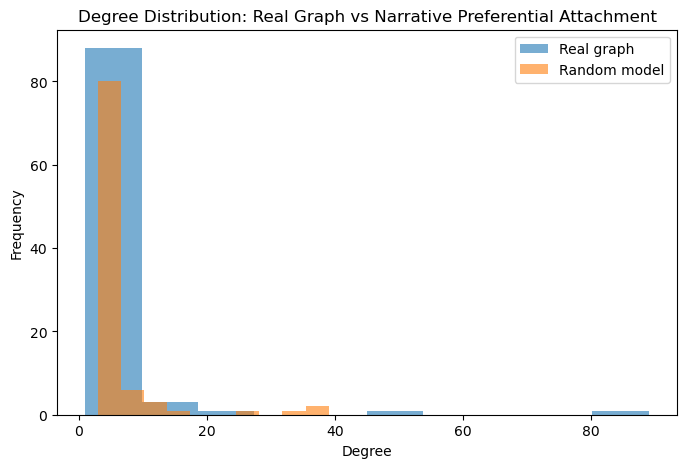

In [45]:
plt.figure(figsize=(8, 5))
plt.hist(real_degrees, alpha=0.6, label="Real graph")
plt.hist(random_degrees, alpha=0.6, label="Random model")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution: Real Graph vs Narrative Preferential Attachment")
plt.legend()
plt.show()

Some observations and comments as well as motivations:

For Week 9, I chose to use an invented variant of the preferential attachment model. This seemed more appropriate than an Erdős–Rényi model because the Forrest Gump graph is not evenly random. It contains clear hub characters, especially Forrest and Jenny, who connect many different parts of the story.

The model I used is a narrative preferential attachment model. New nodes usually attach preferentially to already well-connected nodes, but with an additional probability of attaching directly to one of the strongest hubs. This reflects the structure of a movie narrative, where new minor characters often appear through their relationship to central characters.

The generated graph was created with the same number of nodes as the real graph and approximately the same average degree. I then compared the real graph and the generated graph using average clustering, transitivity, average shortest path length, diameter, and the degree distribution.

The random model reproduced the broad hub-based structure of the real network, especially the presence of high-degree nodes. However, the real Forrest Gump graph showed more narrative-specific structure. Some groups of characters are connected because they belong to the same life chapter, such as childhood, military service, media appearances, or Jenny’s social world. These structured story communities are difficult for a random graph model to fully reproduce.

Overall, the comparison suggests that preferential attachment is a better baseline than a purely random Erdős–Rényi graph, because the movie network is strongly organised around central characters. However, the real graph is not only hub-driven; it is also shaped by the sequential and thematic structure of the film.

---
## Week 10
---
a) Depending on what seems more relevant in your graph. Write the code for one of the
following alternative model:
- Threshold model synchroneous,
- Threshold model asynchroneous (random order),
- Fractional Threshold model synchroneous,
- Fractional Threshold model (random order).
- Independent Cascade model,
- Bass contagion model,
- SIS model,
- A variant that seems pertinent in your graph.


b) Investigate different scenario of outbreak in your graph (different size of outbreaks,
different origins, different parameters).

In [46]:
G_week10 = G_real.copy()

In [47]:
def independent_cascade(G, initial_active, p=0.2, max_steps=50, seed=None):
    """
    Independent Cascade model.
    Active nodes get one chance to activate each inactive neighbour.
    """
    if seed is not None:
        random.seed(seed)
    
    active = set(initial_active)
    newly_active = set(initial_active)
    
    history = [len(active)]
    
    step = 0
    
    while newly_active and step < max_steps:
        next_active = set()
        
        for node in newly_active:
            for neighbour in G.neighbors(node):
                if neighbour not in active:
                    if random.random() < p:
                        next_active.add(neighbour)
        
        active.update(next_active)
        newly_active = next_active
        history.append(len(active))
        step += 1
    
    return active, history

In [48]:
def get_node_id_by_label(G, label):
    for node, data in G.nodes(data=True):
        if data["label"] == label:
            return node
    return None

# This should be ok but we add this one more time to be sure
forrest_id = get_node_id_by_label(G_week10, "FORREST")
jenny_id = get_node_id_by_label(G_week10, "JENNY")
lt_dan_id = get_node_id_by_label(G_week10, "LT DAN")
bubba_id = get_node_id_by_label(G_week10, "BUBBA")

print(forrest_id, jenny_id, lt_dan_id, bubba_id)

35 41 48 15


In [49]:
def run_scenarios(G, origins, probabilities, runs=50):
    results = []
    
    for origin_name, origin_nodes in origins.items():
        for p in probabilities:
            outbreak_sizes = []
            
            for r in range(runs):
                active, history = independent_cascade(
                    G,
                    initial_active=origin_nodes,
                    p=p,
                    seed=r
                )
                outbreak_sizes.append(len(active))
            
            results.append({
                "origin": origin_name,
                "p": p,
                "average_outbreak_size": sum(outbreak_sizes) / len(outbreak_sizes),
                "min_outbreak_size": min(outbreak_sizes),
                "max_outbreak_size": max(outbreak_sizes),
                "average_outbreak_fraction": (sum(outbreak_sizes) / len(outbreak_sizes)) / G.number_of_nodes()
            })
    
    return pd.DataFrame(results)

In [50]:
origins = {
    "Forrest only": [forrest_id],
    "Jenny only": [jenny_id],
    "Lt Dan only": [lt_dan_id],
    "Bubba only": [bubba_id],
    "Forrest + Jenny": [forrest_id, jenny_id],
    "Military origin": [lt_dan_id, bubba_id]
}

probabilities = [0.05, 0.10, 0.20, 0.30, 0.50]

week10_results = run_scenarios(
    G_week10,
    origins=origins,
    probabilities=probabilities,
    runs=100
)

week10_results

,origin,p,average_outbreak_size,min_outbreak_size,max_outbreak_size,average_outbreak_fraction
0,Forrest only,0.05,7.17,1,17,0.076277
1,Forrest only,0.10,17.56,5,39,0.186809
2,Forrest only,0.20,42.20,15,56,0.448936
3,Forrest only,0.30,60.57,49,72,0.644362
4,Forrest only,0.50,79.64,71,88,0.847234
5,Jenny only,0.05,4.99,1,23,0.053085
6,Jenny only,0.10,13.61,2,38,0.144787
7,Jenny only,0.20,42.06,7,59,0.447447
8,Jenny only,0.30,60.37,47,72,0.642234
9,Jenny only,0.50,79.77,70,88,0.848617


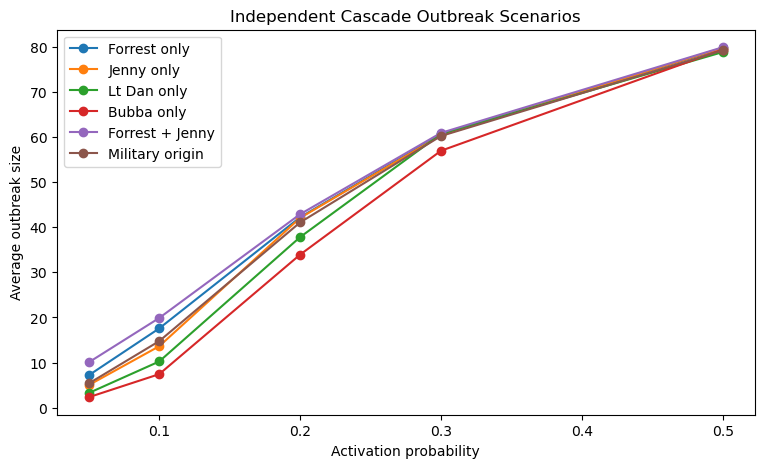

In [51]:
plt.figure(figsize=(9, 5))

for origin in week10_results["origin"].unique():
    subset = week10_results[week10_results["origin"] == origin]
    plt.plot(
        subset["p"],
        subset["average_outbreak_size"],
        marker="o",
        label=origin
    )

plt.xlabel("Activation probability")
plt.ylabel("Average outbreak size")
plt.title("Independent Cascade Outbreak Scenarios")
plt.legend()
plt.show()

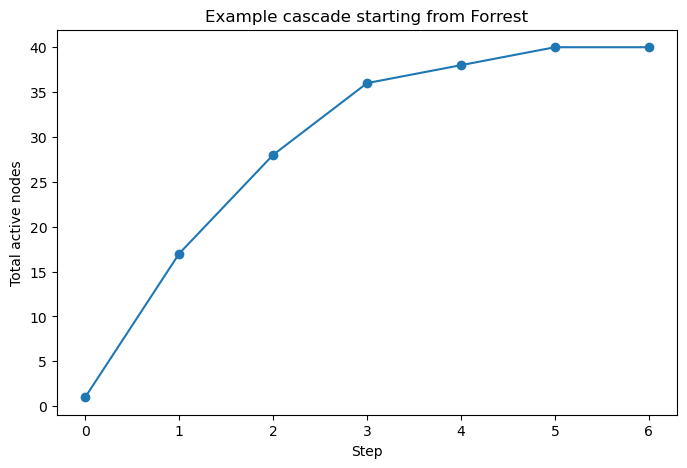

Final outbreak size: 40
Outbreak fraction: 0.425531914893617


In [52]:
# Example single cascade from Forrest

active, history = independent_cascade(
    G_week10,
    initial_active=[forrest_id],
    p=0.2,
    seed=42
)

plt.figure(figsize=(8, 5))
plt.plot(range(len(history)), history, marker="o")
plt.xlabel("Step")
plt.ylabel("Total active nodes")
plt.title("Example cascade starting from Forrest")
plt.show()

print("Final outbreak size:", len(active))
print("Outbreak fraction:", len(active) / G_week10.number_of_nodes())

For Week 10, I used the Independent Cascade model. This seemed appropriate for the Forrest Gump graph because the network can be interpreted as a structure through which narrative attention, influence, or information spreads. In this model, once a node becomes active, it has one chance to activate each inactive neighbour with probability p.

I tested different outbreak scenarios by changing both the origin node and the activation probability. I compared cascades beginning from central characters such as Forrest and Jenny with cascades beginning from more local characters such as Bubba and Lt Dan. I also tested multi-source outbreaks such as Forrest + Jenny and a military-origin scenario.

The results show that the origin of the cascade matters strongly. Outbreaks starting from Forrest generally spread further because Forrest is the main hub of the network and connects many different parts of the story. Jenny also produces large cascades because she connects to several narrative communities. More local origins, such as Bubba or Lt Dan, usually produce smaller outbreaks unless the activation probability is high.

As expected, increasing the activation probability increased the average outbreak size. At low probabilities, cascades often remained local. At higher probabilities, the cascade could reach a much larger fraction of the graph.

This suggests that the Forrest Gump network is vulnerable to cascades starting from central narrative characters. However, cascades starting from peripheral or chapter-specific characters are more contained.